# Signals of Prestige in Film Discourse: A Transformer-Based Approach to Predicting Best Picture Winners

### By: Ed Hou, Si Qin Huang, Alejandro Mendez

---

Click here to [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/s-huang23/nlp-oscar-predictor/blob/model_dev/oscar_predictor.ipynb)


In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import os
import glob
import json
import pandas as pd
import numpy as np
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel, AutoModel, AutoTokenizer
from typing import Optional

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp

In [3]:
# Mount drive (If manually uploaded data, mount drive)
# from google.colab import drive
# drive.mount('/content/drive')

# Clone only the data folder from the repository (if not already present)
if not os.path.exists("data"):
    os.system("rm -rf /tmp/nlp-repo")
    ret = os.system("git clone --depth=1 https://github.com/s-huang23/nlp-oscar-predictor.git /tmp/nlp-repo")
    if ret == 0:
        os.system("cp -r /tmp/nlp-repo/data .")
        print("Data cloned successfully.")
    else:
        print("ERROR: git clone failed. Check that the repo is public and the URL is correct.")

print("data/ exists:", os.path.exists("data"))
print("data/raw/ exists:", os.path.exists("data/raw"))

Data cloned successfully.
data/ exists: True
data/raw/ exists: True


## Dataset (NEEDS TO BE IMPLEMENTED)

Load iMDb data from kaggle and web-scraped reviews from Metacritic

#### Metacritic data

In [4]:
# Load metacritic dataset
# metacritic_df = pd.read_csv("/content/drive/MyDrive/metacritic_reviews.csv") # If data is uploaded to drive
metacritic_df = pd.read_csv("data/raw/metacritic_reviews.csv")
print(metacritic_df.shape)
metacritic_df.head()

(6643, 13)


,ceremony_year,release_year,film_title,winner,metacritic_slug,metacritic_url,critic_review_page,review_date,critic_score,publication,author,quote,full_review_url
0,2010,2009,Avatar,0,avatar,https://www.metacritic.com/movie/avatar/,https://www.metacritic.com/movie/avatar/critic...,NaN,100,The Hollywood Reporter,Kirk Honeycutt,"A fully believable, flesh-and-blood (albeit no...",http://www.hollywoodreporter.com/hr/film-revie...
1,2010,2009,Avatar,0,avatar,https://www.metacritic.com/movie/avatar/,https://www.metacritic.com/movie/avatar/critic...,NaN,100,Empire,Chris Hewitt (1),"It's been twelve years since ""Titanic,"" but th...",http://www.empireonline.com/reviews/reviewcomp...
2,2010,2009,Avatar,0,avatar,https://www.metacritic.com/movie/avatar/,https://www.metacritic.com/movie/avatar/critic...,NaN,90,Variety,Todd McCarthy,"Avatar is all-enveloping and transporting, wit...",http://www.variety.com/review/VE1117941773.htm...
3,2010,2009,Avatar,0,avatar,https://www.metacritic.com/movie/avatar/,https://www.metacritic.com/movie/avatar/critic...,NaN,100,Chicago Sun-Times,Roger Ebert,"Once again, [Cameron] has silenced the doubter...",http://rogerebert.suntimes.com/apps/pbcs.dll/a...
4,2010,2009,Avatar,0,avatar,https://www.metacritic.com/movie/avatar/,https://www.metacritic.com/movie/avatar/critic...,NaN,75,Chicago Tribune,Michael Phillips,The first 90 minutes of Avatar are pretty terr...,http://featuresblogs.chicagotribune.com/talkin...


#### Kaggle iMDb data

In [5]:
# Load nominees dataset
# nominees_df = pd.read_csv("/content/drive/MyDrive/nominees.csv") # If data is uploaded to drive
nominees_df   = pd.read_csv("data/nominees.csv")
print(nominees_df.shape)
nominees_df.head()

(136, 5)


,ceremony_year,film_title,release_year,winner,metacritic_slug
0,2010,Avatar,2009,0,avatar
1,2010,The Blind Side,2009,0,the-blind-side
2,2010,District 9,2009,0,district-9
3,2010,An Education,2009,0,an-education
4,2010,The Hurt Locker,2009,1,the-hurt-locker


In [6]:
# Download latest version of data from kaggle
path = kagglehub.dataset_download("ebiswas/imdb-review-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-review-dataset' dataset.
Path to dataset files: /kaggle/input/imdb-review-dataset


In [7]:
# Keep Metacritic / nominee titles as the canonical film titles.
# Kaggle IMDb titles sometimes include alternate punctuation, accents, or IMDb roman-numeral suffixes.
# These variants are mapped back to the Metacritic title before merging.
imdb_to_metacritic_title = {
    "Extremely Loud & Incredibly Close": "Extremely Loud and Incredibly Close",
    "Les Misérables": "Les Miserables",
    "Once Upon a Time... In Hollywood": "Once Upon a Time ... in Hollywood",
    "Hell or High Water (II)": "Hell or High Water",
    "Boyhood (I)": "Boyhood",
    "Arrival (II)": "Arrival",
    "Get Out (I)": "Get Out",
    "Moonlight (I)": "Moonlight",
    "Room (I)": "Room",
    "Spotlight (I)": "Spotlight",
    "The Artist (I)": "The Artist",
    "Vice (I)": "Vice",
}

# nominees_df and metacritic_df already use canonical Metacritic titles.
# Apply imdb_to_metacritic_title to reviews_df["movie"] after extracting IMDb movie titles.


In [8]:
# print(os.listdir(path))

In [9]:
# Combine all parts of json
all_files = glob.glob(os.path.join(path, "part-*.json"))

records = []
for f in all_files:
    with open(f) as fh:
        records.extend(json.load(fh))

# Convert to dataframe
reviews_df = pd.DataFrame(records)
print(reviews_df.shape)
reviews_df.head()

(5571499, 9)


,review_id,reviewer,movie,rating,review_summary,review_date,spoiler_tag,review_detail,helpful
0,rw1133942,OriginalMovieBuff21,Kill Bill: Vol. 2 (2004),8,Good follow up that answers all the questions,24 July 2005,0,"After seeing Tarantino's Kill Bill Vol: 1, I g...","[0, 1]"
1,rw1133943,sentra14,Journey to the Unknown (1968– ),None,Excellent series,24 July 2005,0,"I have the entire series on video, taped mostl...","[11, 11]"
2,rw1133946,GreenwheelFan2002,The Island (2005),9,"Not just about action, but about survival...",24 July 2005,0,Once again the critics prove themselves as mor...,"[2, 5]"
3,rw1133948,itsascreambaby,Win a Date with Tad Hamilton! (2004),3,Falls under the category: seen it a million ti...,24 July 2005,0,This IS a film that has been done too many tim...,"[2, 3]"
4,rw1133949,OriginalMovieBuff21,Saturday Night Live: The Best of Chris Farley ...,10,"Before Tommy Boy and Black Sheep, there was Sa...",24 July 2005,0,Chris Farley is one of my favorite comedians a...,"[4, 4]"


In [10]:
# Extract title and year from "Movie Title (YEAR)" format
reviews_df["release_year"] = (
    reviews_df["movie"]
    .str.extract(r'\((\d{4})')   # grab the first 4-digit year after '('
    .astype(float)
    .astype("Int64")
)

reviews_df["movie"] = (
    reviews_df["movie"]
    .str.replace(r'\s*\(\d{4}[^)]*\)', '', regex=True)  # remove anything from (YEAR...  to )
    .str.strip()
)

# Convert Kaggle IMDb title variants to canonical Metacritic / nominee titles.
reviews_df["movie"] = reviews_df["movie"].replace(imdb_to_metacritic_title)

print(reviews_df[["movie", "release_year"]].head(10))


                                           movie  release_year
0                              Kill Bill: Vol. 2          2004
1                         Journey to the Unknown          1968
2                                     The Island          2005
3                  Win a Date with Tad Hamilton!          2004
4  Saturday Night Live: The Best of Chris Farley          2000
5                                    Outlaw Star          1998
6                                    The Aviator          2004
7      Star Wars: Episode I - The Phantom Menace          1999
8                          The Amityville Horror          2005
9                                  Flying Tigers          1942


In [11]:
# Filter and merge using both columns
filtered_reviews = reviews_df[
    reviews_df["movie"].isin(nominees_df["film_title"]) &
    reviews_df["release_year"].isin(nominees_df["release_year"])
].copy()

print(f"Total reviews matched: {len(filtered_reviews)}")
print(f"Unique films matched : {filtered_reviews['movie'].nunique()} / {len(nominees_df)}")

imdb_df = filtered_reviews.merge(
    nominees_df[["film_title", "release_year", "ceremony_year", "winner"]],
    left_on=["movie", "release_year"],
    right_on=["film_title", "release_year"],
    how="left"
)

# Drop values with NAs that don't match up
imdb_df = imdb_df.dropna(subset=["winner"])
# Fix winner and ceremony_year column formatting
imdb_df["winner"] = imdb_df["winner"].astype(int)
imdb_df["ceremony_year"] = imdb_df["ceremony_year"].astype(int)

print(imdb_df.shape)
imdb_df.head()

Total reviews matched: 100957
Unique films matched : 108 / 136
(100162, 13)


,review_id,reviewer,movie,rating,review_summary,review_date,spoiler_tag,review_detail,helpful,release_year,film_title,ceremony_year,winner
0,rw2073111,jdesando,Up,None,A Summer Upper,28 May 2009,0,"""The thirst for adventure is the vent which De...","[7, 15]",2009,Up,2010,0
1,rw2073175,nirmal_vijay,Up,10,Up you go.......,28 May 2009,0,10 in a row for Pixar. Full of depth in imagin...,"[3, 9]",2009,Up,2010,0
2,rw2073244,TheWylde,Up,8,Pixar's best since Toy Story 2,29 May 2009,0,"Admittedly, I don't really like children's mov...","[1, 11]",2009,Up,2010,0
3,rw2073354,aleexx_1920,Up,10,up is pixar's magic,29 May 2009,0,OK I was never interested in seeing this film ...,"[2, 8]",2009,Up,2010,0
4,rw2073435,gro,Up,4,Up is Down,29 May 2009,1,"In the past couple months I've seen Coraline, ...","[13, 42]",2009,Up,2010,0


In [12]:
# Drop unneeded columns
imdb_df = imdb_df.drop(columns=["movie", "review_summary", "spoiler_tag", "helpful"])

# Strip disambiguation suffixes like (I), (II) from film titles.
for df in [imdb_df, nominees_df, metacritic_df]:
    df["film_title"] = df["film_title"].str.replace(r'\s*\([IV]+\)$', '', regex=True).str.strip()

# Rating is useful for possible later features; keep it numeric.
imdb_df["rating"] = pd.to_numeric(imdb_df["rating"], errors="coerce")

# Keep the model scope used downstream in this notebook.
nominees_df_filtered = nominees_df[
    (nominees_df["ceremony_year"] >= 2012) &
    (nominees_df["ceremony_year"] <= 2020)
].copy()

print(imdb_df.columns.tolist())
print(imdb_df["winner"].value_counts())
imdb_df.head()


['review_id', 'reviewer', 'rating', 'review_date', 'review_detail', 'release_year', 'film_title', 'ceremony_year', 'winner']
winner
0    88850
1    11312
Name: count, dtype: int64


,review_id,reviewer,rating,review_date,review_detail,release_year,film_title,ceremony_year,winner
0,rw2073111,jdesando,NaN,28 May 2009,"""The thirst for adventure is the vent which De...",2009,Up,2010,0
1,rw2073175,nirmal_vijay,10.0,28 May 2009,10 in a row for Pixar. Full of depth in imagin...,2009,Up,2010,0
2,rw2073244,TheWylde,8.0,29 May 2009,"Admittedly, I don't really like children's mov...",2009,Up,2010,0
3,rw2073354,aleexx_1920,10.0,29 May 2009,OK I was never interested in seeing this film ...,2009,Up,2010,0
4,rw2073435,gro,4.0,29 May 2009,"In the past couple months I've seen Coraline, ...",2009,Up,2010,0


## Pre-processing

Both IMDb and Metacritic reviews are processed with the same core leakage-control and cleanup steps.

Implemented steps:
  - Filter to Oscar ceremony years 2012-2020
  - Filter each review to before the ceremony date: `review_date < ceremony_date`
  - Remove rows with invalid dates, short or empty text, and duplicate review text
  - Clean review text into `clean_text` while preserving emoji and sentiment-bearing punctuation
  - Add `film_review_count` and `film_review_weight` so films with more reviews do not dominate downstream aggregation

The ceremony date is excluded because review timestamps are date-only; excluding Oscar day avoids accidentally including reviews written after the winner was announced.


In [13]:
# Preprocess IMDb and Metacritic reviews.
# Core window: review_date < ceremony_date.
import re

START_YEAR = 2012
END_YEAR = 2020
MIN_TEXT_CHARS = 20

# windows_path = "/content/drive/MyDrive/oscar_windows.csv"
oscar_windows = pd.read_csv("data/oscar_windows.csv", parse_dates=["nomination_date", "ceremony_date"])


def clean_text(value):
    """Normalize review text while preserving the words used by reviewers."""
    text = "" if pd.isna(value) else str(value)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# Sanity check: emoji can carry sentiment, so preprocessing should keep them.
assert clean_text("Loved it 😭!") == "Loved it 😭!"


def summarize_reviews(label, df):
    film_count = df[["ceremony_year", "film_title"]].drop_duplicates().shape[0]
    years = sorted(df["ceremony_year"].dropna().astype(int).unique().tolist()) if len(df) else []
    print(f"{label:<36} rows={len(df):>6} films={film_count:>3} years={years}")


def preprocess_reviews(df, source_name, text_col):
    """Apply project preprocessing to one review source."""
    print(f"\n{source_name.upper()} preprocessing")
    summarize_reviews("raw", df)

    working = df[
        (df["ceremony_year"] >= START_YEAR) &
        (df["ceremony_year"] <= END_YEAR)
    ].copy()
    summarize_reviews("after ceremony-year filter", working)

    working = working.merge(oscar_windows, on="ceremony_year", how="left", validate="many_to_one")
    working["review_date_parsed"] = pd.to_datetime(working["review_date"], errors="coerce")

    invalid_dates = working["review_date_parsed"].isna().sum()
    if invalid_dates:
        print(f"dropped invalid review dates: {invalid_dates}")

    in_window = (
        working["review_date_parsed"].notna()
        & (working["review_date_parsed"] < working["ceremony_date"])
    )
    working = working[in_window].copy()
    summarize_reviews("after ceremony-date filter", working)

    working["clean_text"] = working[text_col].map(clean_text)
    before = len(working)
    working = working[working["clean_text"].str.len() >= MIN_TEXT_CHARS].copy()
    print(f"dropped short/empty reviews: {before - len(working)}")

    dedupe_cols = ["ceremony_year", "film_title", "clean_text"]
    if source_name == "imdb" and "reviewer" in working.columns:
        dedupe_cols.insert(2, "reviewer")
    if source_name == "metacritic" and "publication" in working.columns:
        dedupe_cols.insert(2, "publication")

    before = len(working)
    working = working.drop_duplicates(subset=dedupe_cols).copy()
    print(f"dropped duplicate reviews: {before - len(working)}")

    working["film_review_count"] = working.groupby(
        ["ceremony_year", "film_title"]
    )["clean_text"].transform("size")
    working["film_review_weight"] = 1.0 / working["film_review_count"]

    summarize_reviews("final", working)
    return working


imdb_df = preprocess_reviews(imdb_df, "imdb", "review_detail")
metacritic_df = preprocess_reviews(metacritic_df, "metacritic", "quote")



IMDB preprocessing
raw                                  rows=100162 films= 99 years=[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
after ceremony-year filter           rows= 82997 films= 78 years=[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
after ceremony-date filter           rows= 42149 films= 78 years=[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
dropped short/empty reviews: 2
dropped duplicate reviews: 13
final                                rows= 42134 films= 78 years=[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

METACRITIC preprocessing
raw                                  rows=  6643 films=136 years=[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
after ceremony-year filter           rows=  3787 films= 78 years=[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
after ceremony-date filter           rows=  3730 films= 78 years=[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

In [14]:
meta_films = set(metacritic_df["film_title"].unique())
imdb_films = set(imdb_df["film_title"].unique())

print("In Metacritic but NOT in IMDb:")
print(meta_films - imdb_films)

In Metacritic but NOT in IMDb:
set()


## Model

**Pipeline**: <br>
BERT  â†’ [CLS] per review  â†’ WeightedAggregator â†’ review film vector <br>
BERTweet â†’ [CLS] per tweet â†’ WeightedAggregator â†’ tweet film vector <br>
Concatenate â†’ Classification Head â†’ P(win)

**Weighted Aggregator**: aggregates review embeddings from BERT and BERTweet into a single film vector

**Model 1 - Transformer with Cross-Attention between IMDb user + Metacritic critic reviews encoded on shared RoBERTa Base**

**Hypothesis:** domain-separated encoding with bidirectional
cross-attention between critic and audience discourse captures
complementary signals that improve Best Picture prediction

**Features**
- RoBERTa base: improved version of BERT with 10x training data and improved hyperparameter tuning & dynamic masking
- Segmented feature space of IMDb user reviews and Metacritic reviews
- Both review streams pass through 2 self-attention layers, allowing each review to update its representation by attending to all other reviews of the same film
- Multi-head
- Cross-attention: explore relation between IMDb user reviews and Metacritic critic reviews
- Fusion layers: difference and product instead of simple concatenation

**New cached encoder for speed**

In [15]:
# ── STEP 1: ENCODER ONLY — used once to precompute ────────────────────────────
# Extract just the RoBERTa encoding portion from OscarPredictorAttention
# so we can run it once and cache results
from torch.utils.data import Dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torch.utils.data import Dataset, DataLoader

class OscarCohortDataset(Dataset):
    """Build one tokenized nominee cohort per ceremony year."""
    def __init__(self, nominees_df, metacritic_df, imdb_df, tokenizer,
                 max_critic_reviews=40, max_imdb_reviews=50, max_len=128):
        self.nominees_df = nominees_df.copy()
        self.metacritic_df = metacritic_df.copy()
        self.imdb_df = imdb_df.copy()
        self.tokenizer = tokenizer
        self.max_critic_reviews = max_critic_reviews
        self.max_imdb_reviews = max_imdb_reviews
        self.max_len = max_len

        for df in [self.nominees_df, self.metacritic_df, self.imdb_df]:
            df["ceremony_year"] = df["ceremony_year"].astype(int)
            df["film_title"] = df["film_title"].astype(str)

        self.critic_text_col = "clean_text" if "clean_text" in self.metacritic_df.columns else "quote"
        self.imdb_text_col = "clean_text" if "clean_text" in self.imdb_df.columns else "review_detail"
        self.years = sorted(self.nominees_df["ceremony_year"].dropna().astype(int).unique().tolist())

    def __len__(self):
        return len(self.years)

    def _reviews_for_film(self, df, year, film, text_col, max_reviews):
        reviews = df[(df["ceremony_year"] == year) & (df["film_title"] == film)].copy()
        if "review_date_parsed" in reviews.columns:
            reviews = reviews.sort_values("review_date_parsed")
        elif "review_date" in reviews.columns:
            reviews = reviews.sort_values("review_date")

        texts = reviews[text_col].dropna().astype(str).tolist()[:max_reviews]
        return [text for text in texts if text.strip()]

    def _tokenize_reviews(self, texts, max_reviews):
        encoded = self.tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        ) if texts else None

        input_ids = torch.zeros((max_reviews, self.max_len), dtype=torch.long)
        attention_mask = torch.zeros((max_reviews, self.max_len), dtype=torch.long)

        if encoded is not None:
            n_reviews = min(len(texts), max_reviews)
            input_ids[:n_reviews] = encoded["input_ids"][:n_reviews]
            attention_mask[:n_reviews] = encoded["attention_mask"][:n_reviews]

        return input_ids, attention_mask

    def __getitem__(self, idx):
        year = self.years[idx]
        nominees = (
            self.nominees_df[self.nominees_df["ceremony_year"] == year]
            .drop_duplicates(subset=["film_title"])
            .sort_values("film_title")
            .reset_index(drop=True)
        )
        films = nominees["film_title"].tolist()
        winner_rows = nominees.index[nominees["winner"].astype(int) == 1].tolist()
        if not winner_rows:
            raise ValueError(f"No winner marked for ceremony year {year}")
        winner_idx = winner_rows[0]

        critic_ids, critic_masks, imdb_ids, imdb_masks = [], [], [], []
        for film in films:
            critic_texts = self._reviews_for_film(
                self.metacritic_df, year, film, self.critic_text_col, self.max_critic_reviews
            )
            imdb_texts = self._reviews_for_film(
                self.imdb_df, year, film, self.imdb_text_col, self.max_imdb_reviews
            )

            c_ids, c_mask = self._tokenize_reviews(critic_texts, self.max_critic_reviews)
            i_ids, i_mask = self._tokenize_reviews(imdb_texts, self.max_imdb_reviews)
            critic_ids.append(c_ids)
            critic_masks.append(c_mask)
            imdb_ids.append(i_ids)
            imdb_masks.append(i_mask)

        return {
            "year": torch.tensor(year, dtype=torch.long),
            "films": films,
            "critic_input_ids": torch.stack(critic_ids),
            "critic_attention_mask": torch.stack(critic_masks),
            "imdb_input_ids": torch.stack(imdb_ids),
            "imdb_attention_mask": torch.stack(imdb_masks),
            "winner_idx": torch.tensor(winner_idx, dtype=torch.long),
        }

class RoBERTaEncoder(nn.Module):
    """Lightweight wrapper — just the frozen encoder + mean pool."""
    def __init__(self, model_name="roberta-base"):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        for param in self.encoder.parameters():
            param.requires_grad = False

    @torch.no_grad()
    def encode_reviews(self, input_ids, attention_mask):
        """
        input_ids      : [num_reviews, seq_len]
        attention_mask : [num_reviews, seq_len]
        returns        : [num_reviews, 768]
        """
        outputs  = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden   = outputs.last_hidden_state
        mask_exp = attention_mask.unsqueeze(-1).float()
        pooled   = (hidden * mask_exp).sum(dim=1) / \
                   mask_exp.sum(dim=1).clamp(min=1e-8)
        return pooled  # [num_reviews, 768]


# ── STEP 2: PRECOMPUTE AND CACHE ───────────────────────────────────────────────
def precompute_and_cache(nominees_df, metacritic_df, imdb_df,
                          tokenizer, device,
                          max_critic_reviews=40, max_imdb_reviews=50,
                          max_len=128, save_path="oscar_embeddings.pt"):
    """
    Runs RoBERTa once over all reviews for all films across all years.
    Saves a cache of [num_reviews, 768] tensors per film per year.
    Subsequent training epochs load from cache — no RoBERTa forward passes.
    """
    print("Precomputing RoBERTa embeddings...")
    encoder = RoBERTaEncoder().to(device)
    encoder.eval()

    # Reuse existing dataset class just for tokenization
    full_dataset = OscarCohortDataset(
        nominees_df, metacritic_df, imdb_df, tokenizer,
        max_critic_reviews=max_critic_reviews,
        max_imdb_reviews=max_imdb_reviews,
        max_len=max_len
    )

    cache = {}

    for cohort_idx in range(len(full_dataset)):
        sample = full_dataset[cohort_idx]
        year   = sample["year"].item() if torch.is_tensor(sample["year"]) \
                 else int(sample["year"])
        films  = sample["films"]

        print(f"  Encoding year {year} — {len(films)} films")
        cache[year] = []

        # critic_input_ids: [n_films, max_critic_reviews, seq_len]
        critic_ids  = sample["critic_input_ids"]
        critic_mask = sample["critic_attention_mask"]
        imdb_ids    = sample["imdb_input_ids"]
        imdb_mask   = sample["imdb_attention_mask"]

        for i, film in enumerate(films):
            # Encode critic reviews for this film
            c_ids  = critic_ids[i].to(device)   # [max_critic_reviews, seq_len]
            c_mask = critic_mask[i].to(device)
            c_emb  = encoder.encode_reviews(c_ids, c_mask)  # [max_critic, 768]

            # Encode IMDb reviews for this film
            i_ids  = imdb_ids[i].to(device)     # [max_imdb_reviews, seq_len]
            i_mask = imdb_mask[i].to(device)
            i_emb  = encoder.encode_reviews(i_ids, i_mask)  # [max_imdb, 768]

            # Also cache the padding masks for attention layers
            # True = padded review (all zeros), used by TransformerEncoder
            c_pad_mask = (c_mask.sum(dim=-1) == 0)  # [max_critic_reviews]
            i_pad_mask = (i_mask.sum(dim=-1) == 0)  # [max_imdb_reviews]

            cache[year].append({
                "film":          film,
                "critic_emb":    c_emb.cpu(),        # [max_critic, 768]
                "imdb_emb":      i_emb.cpu(),        # [max_imdb, 768]
                "critic_pad":    c_pad_mask.cpu(),   # [max_critic]
                "imdb_pad":      i_pad_mask.cpu(),   # [max_imdb]
                "winner_idx":    sample["winner_idx"].item(),
            })

    torch.save(cache, save_path)
    # print(f"Saved to Drive: {save_path_drive}")
    # print(f"Saved embeddings → {save_path}")
    print(f"Years cached: {sorted(cache.keys())}")
    return cache


# ── STEP 3: CACHED DATASET ────────────────────────────────────────────────────
class OscarEmbeddingDataset(Dataset):
    """
    Loads precomputed embeddings instead of raw text.
    Each item is one cohort year — [n_films, max_reviews, 768] tensors.
    Training epochs are now seconds not minutes.
    """
    def __init__(self, cache, years):
        self.cohorts = []

        for year in years:
            if year not in cache:
                print(f"Warning: year {year} not in cache, skipping")
                continue

            film_data  = cache[year]
            n_films    = len(film_data)
            winner_idx = film_data[0]["winner_idx"]  # same for all films in year

            critic_embs = torch.stack([f["critic_emb"] for f in film_data])  # [n_films, max_critic, 768]
            imdb_embs   = torch.stack([f["imdb_emb"]   for f in film_data])  # [n_films, max_imdb,   768]
            critic_pads = torch.stack([f["critic_pad"]  for f in film_data])  # [n_films, max_critic]
            imdb_pads   = torch.stack([f["imdb_pad"]    for f in film_data])  # [n_films, max_imdb]
            films       = [f["film"] for f in film_data]

            self.cohorts.append({
                "year":        year,
                "films":       films,
                "critic_embs": critic_embs,
                "imdb_embs":   imdb_embs,
                "critic_pads": critic_pads,
                "imdb_pads":   imdb_pads,
                "winner_idx":  torch.tensor(winner_idx, dtype=torch.long),
            })

    def __len__(self):
        return len(self.cohorts)

    def __getitem__(self, idx):
        return self.cohorts[idx]


# ── STEP 4: MODIFIED MODEL — takes embeddings not raw tokens ──────────────────
class OscarPredictorAttentionCached(nn.Module):
    """
    Same architecture as OscarPredictorAttention but takes precomputed
    [n_films, num_reviews, 768] embeddings instead of raw token ids.
    RoBERTa encoding removed — handled by precompute step.
    """
    def __init__(self, hidden_dim=768, num_heads=8,
                 num_self_attn_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Self-attention over reviews within each stream
        critic_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True
        )
        self.critic_self_attn = nn.TransformerEncoder(
            critic_layer, num_layers=num_self_attn_layers
        )

        imdb_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True
        )
        self.imdb_self_attn = nn.TransformerEncoder(
            imdb_layer, num_layers=num_self_attn_layers
        )

        # Cross-attention between streams
        self.cross_attn_critic_to_imdb = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.cross_attn_imdb_to_critic = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )

        self.norm_critic_self  = nn.LayerNorm(hidden_dim)
        self.norm_imdb_self    = nn.LayerNorm(hidden_dim)
        self.norm_critic_cross = nn.LayerNorm(hidden_dim)
        self.norm_imdb_cross   = nn.LayerNorm(hidden_dim)

        # Fusion
        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim * 4, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, critic_embs, critic_pad_mask,
                      imdb_embs,   imdb_pad_mask):
        """
        critic_embs    : [n_films, max_critic_reviews, 768]
        critic_pad_mask: [n_films, max_critic_reviews]  True=padded
        imdb_embs      : [n_films, max_imdb_reviews,   768]
        imdb_pad_mask  : [n_films, max_imdb_reviews]    True=padded
        returns        : [n_films, 1] raw logits
        """
        h_critic = critic_embs
        h_imdb   = imdb_embs

        # Self-attention within each stream
        h_critic_self = self.critic_self_attn(
            h_critic, src_key_padding_mask=critic_pad_mask
        )
        h_critic = self.norm_critic_self(h_critic + h_critic_self)

        h_imdb_self = self.imdb_self_attn(
            h_imdb, src_key_padding_mask=imdb_pad_mask
        )
        h_imdb = self.norm_imdb_self(h_imdb + h_imdb_self)

        # Cross-attention between streams
        h_critic_cross, _ = self.cross_attn_critic_to_imdb(
            query=h_critic, key=h_imdb, value=h_imdb,
            key_padding_mask=imdb_pad_mask
        )
        h_critic = self.norm_critic_cross(h_critic + h_critic_cross)

        h_imdb_cross, _ = self.cross_attn_imdb_to_critic(
            query=h_imdb, key=h_critic, value=h_critic,
            key_padding_mask=critic_pad_mask
        )
        h_imdb = self.norm_imdb_cross(h_imdb + h_imdb_cross)

        # Pool to one vector per film
        c_critic = h_critic.mean(dim=1)   # [n_films, 768]
        c_imdb   = h_imdb.mean(dim=1)     # [n_films, 768]

        diff    = c_critic - c_imdb
        product = c_critic * c_imdb
        fused   = torch.cat([c_critic, c_imdb, diff, product], dim=-1)

        return self.scorer(fused)         # [n_films, 1]


# ── STEP 5: FAST TRAINING LOOP ────────────────────────────────────────────────
def train_step_cached(model, optimizer, batch, device):
    model.train()
    optimizer.zero_grad()

    critic_embs = batch["critic_embs"].squeeze(0).to(device)   # [n_films, max_critic, 768]
    imdb_embs   = batch["imdb_embs"].squeeze(0).to(device)
    critic_pads = batch["critic_pads"].squeeze(0).to(device)   # [n_films, max_critic]
    imdb_pads   = batch["imdb_pads"].squeeze(0).to(device)
    winner_idx  = batch["winner_idx"].squeeze().to(device)

    logits = model(critic_embs, critic_pads, imdb_embs, imdb_pads)

    loss = nn.CrossEntropyLoss()(
        logits.squeeze(-1).unsqueeze(0),
        winner_idx.unsqueeze(0)
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    probs     = torch.softmax(logits.squeeze(-1), dim=0)
    predicted = probs.argmax().item()
    correct   = (predicted == winner_idx.item())

    return loss.item(), correct, probs.detach().cpu().tolist()


def eval_step_cached(model, batch, device):
    model.eval()
    with torch.no_grad():
        critic_embs = batch["critic_embs"].squeeze(0).to(device)
        imdb_embs   = batch["imdb_embs"].squeeze(0).to(device)
        critic_pads = batch["critic_pads"].squeeze(0).to(device)
        imdb_pads   = batch["imdb_pads"].squeeze(0).to(device)
        winner_idx  = batch["winner_idx"].squeeze().to(device)

        logits = model(critic_embs, critic_pads, imdb_embs, imdb_pads)

        loss = nn.CrossEntropyLoss()(
            logits.squeeze(-1).unsqueeze(0),
            winner_idx.unsqueeze(0)
        )

        probs     = torch.softmax(logits.squeeze(-1), dim=0)
        predicted = probs.argmax().item()
        correct   = (predicted == winner_idx.item())

    return loss.item(), correct, probs.detach().cpu().tolist()


# ── STEP 6: FAST LOOCV ────────────────────────────────────────────────────────
def run_loocv_cached(cache, nominees_df,
                     num_epochs=50, lr=3e-4, device="cpu"):

    all_years = sorted(cache.keys())
    results   = []

    for test_year in all_years:
        print(f"\n{'='*56}")
        print(f"Fold: test year = {test_year}")
        print(f"{'='*56}")

        train_years = [y for y in all_years if y != test_year]

        train_dataset = OscarEmbeddingDataset(cache, train_years)
        test_dataset  = OscarEmbeddingDataset(cache, [test_year])

        train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=True)
        test_loader   = DataLoader(test_dataset,  batch_size=1, shuffle=False)

        model     = OscarPredictorAttentionCached().to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs
        )

        for epoch in range(num_epochs):
            losses, corrects = [], []
            for batch in train_loader:
                loss, correct, _ = train_step_cached(model, optimizer, batch, device)
                losses.append(loss)
                corrects.append(correct)
            scheduler.step()

            if (epoch + 1) % 10 == 0:  # print every 10 epochs
                print(f"  Epoch {epoch+1:03d} | loss {np.mean(losses):.4f} | "
                      f"train acc {sum(corrects)}/{len(corrects)}")

        # Evaluate
        print(f"\n  Results for {test_year}:")
        for batch in test_loader:
            loss, correct, probs = eval_step_cached(model, batch, device)
            films      = batch["films"]
            winner_idx = batch["winner_idx"].squeeze().item()
            pred_idx   = probs.index(max(probs))

            for i, (film, prob) in enumerate(zip(films, probs)):
                w = " ← winner"    if i == winner_idx else ""
                p = " ← predicted" if i == pred_idx   else ""
                print(f"    {film[0]:45s} {prob:.3f}{w}{p}")

            results.append({
                "test_year": test_year,
                "correct":   correct,
                "winner":    films[winner_idx][0],
                "predicted": films[pred_idx][0],
            })

    # Summary
    print(f"\n{'='*56}")
    print(f"LOOCV Summary (cached embeddings)")
    print(f"{'='*56}")
    for r in results:
        mark = "✓" if r["correct"] else "✗"
        print(f"  {mark} {r['test_year']} | "
              f"predicted: {r['predicted']:40s} | "
              f"actual: {r['winner']}")

    accuracy = sum(r["correct"] for r in results) / len(results)
    print(f"\nOverall: {sum(r['correct'] for r in results)}/{len(results)} = {accuracy:.1%}")
    print(f"Random baseline: ~12.5%")
    return results


# ── RUN — do this once current run finishes ────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Precompute once — takes a few minutes, saves to disk
cache = precompute_and_cache(
    nominees_df    = nominees_df_filtered,
    metacritic_df  = metacritic_df,
    imdb_df        = imdb_df,
    tokenizer      = tokenizer,
    device         = device,
    max_critic_reviews = 40,
    max_imdb_reviews   = 50,
    max_len            = 128,
    save_path      = "oscar_embeddings.pt"
)

# If cache already exists on disk, just load it
# cache = torch.load("oscar_embeddings.pt")

# Train with 50 epochs — each epoch is now seconds not minutes
results_cached = run_loocv_cached(
    cache       = cache,
    nominees_df = nominees_df_filtered,
    num_epochs  = 50,
    lr          = 3e-4,
    device      = device
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Encoding year 2012 — 9 films
  Encoding year 2013 — 9 films
  Encoding year 2014 — 9 films
  Encoding year 2015 — 8 films
  Encoding year 2016 — 8 films
  Encoding year 2017 — 9 films
  Encoding year 2018 — 9 films
  Encoding year 2019 — 8 films
  Encoding year 2020 — 9 films
Years cached: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

Fold: test year = 2012
  Epoch 010 | loss 2.3225 | train acc 1/8
  Epoch 020 | loss 2.3428 | train acc 2/8
  Epoch 030 | loss 2.2313 | train acc 0/8
  Epoch 040 | loss 2.2100 | train acc 1/8
  Epoch 050 | loss 2.2982 | train acc 0/8

  Results for 2012:
    Extremely Loud and Incredibly Close           0.111
    Hugo                                          0.111
    Midnight in Paris                             0.111
    Moneyball                                     0.111 ← predicted
    The Artist                                    0.111 ← winner
    The Descendants                               0.111
    The Help                            

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  Epoch 010 | loss 2.2501 | train acc 2/8
  Epoch 020 | loss 2.4677 | train acc 1/8
  Epoch 030 | loss 2.1789 | train acc 1/8
  Epoch 040 | loss 2.1777 | train acc 0/8
  Epoch 050 | loss 2.1313 | train acc 1/8

  Results for 2013:
    Amour                                         0.111
    Argo                                          0.111 ← winner
    Beasts of the Southern Wild                   0.111
    Django Unchained                              0.111
    Les Miserables                                0.111
    Life of Pi                                    0.111
    Lincoln                                       0.111
    Silver Linings Playbook                       0.111
    Zero Dark Thirty                              0.111 ← predicted

Fold: test year = 2014
  Epoch 010 | loss 2.2421 | train acc 1/8
  Epoch 020 | loss 1.9776 | train acc 2/8
  Epoch 030 | loss 2.3499 | train acc 0/8
  Epoch 040 | loss 2.2787 | train acc 0/8
  Epoch 050 | loss 2.2480 | train acc 0/8

  Results

Model 1 Evaluation: basically it's super good in training - basically memorizes the answer, then in the test year is 100% confident on something random in inference.

**Model 2 - Baseline BERT language model**

**Hypothesis:** BERT's pretrained English understanding alone,
without architectural sophistication, provides meaningful signal
above a non-contextual baseline

**Features:**

- One shared encoder: no domain separation between critic and IMDb
- Mean pooling as entire aggregation strategy: every review weighted equally, no attention
- Simple concatenation: no diff, no product, no cross-stream interaction
- One MLP head instead of 8 that learn different review aspects that relate to a Best Picture win (e.g. emotions in writing, logic, commentary related to technical aspects of film)

In [16]:
from sentence_transformers import SentenceTransformer
import torch
import numpy as np

# ── PRECOMPUTE WITH SENTENCE TRANSFORMERS ─────────────────────────────────────
def precompute_st_embeddings(nominees_df, metacritic_df, imdb_df,
                              max_critic_reviews=40, max_imdb_reviews=50,
                              save_path="/content/drive/MyDrive/oscar_st_embeddings.pt",
                              device="cuda"):
    """
    Encode all reviews using sentence-transformers all-mpnet-base-v2.
    Produces genuinely discriminative embeddings — different films
    will have meaningfully different vectors.
    Saves to Drive so you never recompute.
    """
    print("Loading sentence transformer...")
    st_model = SentenceTransformer("all-mpnet-base-v2", device=device)
    st_model.eval()

    cache = {}

    for year, year_nominees in nominees_df.groupby("ceremony_year"):
        print(f"\nEncoding year {year}...")
        films      = year_nominees["film_title"].tolist()
        winner_row = year_nominees[year_nominees["winner"] == 1]

        if winner_row.empty:
            print(f"  Warning: no winner for {year}, skipping")
            continue

        winner_title = winner_row["film_title"].iloc[0]
        if winner_title not in films:
            print(f"  Warning: winner not in films for {year}, skipping")
            continue

        winner_idx = films.index(winner_title)
        cache[year] = []

        for film in films:
            # Get critic reviews
            critic_texts = metacritic_df[
                (metacritic_df["film_title"]    == film) &
                (metacritic_df["ceremony_year"] == year)
            ]["clean_text"].dropna().tolist()[:max_critic_reviews]

            # Get IMDb reviews
            imdb_texts = imdb_df[
                (imdb_df["film_title"]    == film) &
                (imdb_df["ceremony_year"] == year)
            ]["clean_text"].dropna().tolist()[:max_imdb_reviews]

            # Fallbacks
            if not critic_texts:
                print(f"  Warning: no critic reviews for {film}")
                critic_texts = ["no critic reviews available"]
            if not imdb_texts:
                print(f"  Warning: no IMDb reviews for {film}")
                imdb_texts = ["no user reviews available"]

            # Encode — sentence transformers handle batching internally
            with torch.no_grad():
                c_emb = st_model.encode(
                    critic_texts,
                    convert_to_tensor=True,
                    show_progress_bar=False
                )  # [num_critic_reviews, 768]

                i_emb = st_model.encode(
                    imdb_texts,
                    convert_to_tensor=True,
                    show_progress_bar=False
                )  # [num_imdb_reviews, 768]

            # Pad to max_reviews so tensors are uniform shape
            c_emb = pad_embeddings(c_emb, max_critic_reviews)  # [max_critic, 768]
            i_emb = pad_embeddings(i_emb, max_imdb_reviews)    # [max_imdb,   768]

            # Padding masks — True where padded
            c_pad = torch.zeros(max_critic_reviews, dtype=torch.bool)
            i_pad = torch.zeros(max_imdb_reviews,   dtype=torch.bool)
            c_pad[len(critic_texts):] = True
            i_pad[len(imdb_texts):]   = True

            cache[year].append({
                "film":       film,
                "critic_emb": c_emb.cpu(),   # [max_critic, 768]
                "imdb_emb":   i_emb.cpu(),   # [max_imdb,   768]
                "critic_pad": c_pad,         # [max_critic]
                "imdb_pad":   i_pad,         # [max_imdb]
                "winner_idx": winner_idx,
            })

            print(f"  {film}: {len(critic_texts)} critic, {len(imdb_texts)} IMDb reviews")

    torch.save(cache, save_path)
    print(f"\nSaved to {save_path}")
    print(f"Years cached: {sorted(cache.keys())}")
    return cache


def pad_embeddings(emb_tensor, target_len):
    """
    Pad embedding tensor to target_len with zero vectors.
    emb_tensor: [n, 768]
    returns:    [target_len, 768]
    """
    n, dim = emb_tensor.shape
    if n >= target_len:
        return emb_tensor[:target_len]
    pad = torch.zeros(target_len - n, dim, device=emb_tensor.device)
    return torch.cat([emb_tensor, pad], dim=0)


# ── SIMILARITY CHECK ──────────────────────────────────────────────────────────
def check_st_similarities(cache, year=2012):
    """
    Run this immediately after precompute to verify
    embeddings are now discriminative.
    Target: similarities in 0.60-0.85 range.
    """
    cohort = cache[year]
    vecs   = [c["critic_emb"][~c["critic_pad"]].mean(dim=0) for c in cohort]

    print(f"\nSentence transformer critic similarities ({year} cohort):")
    for i in range(len(cohort)):
        for j in range(i+1, len(cohort)):
            sim = torch.nn.functional.cosine_similarity(
                vecs[i].unsqueeze(0),
                vecs[j].unsqueeze(0)
            ).item()
            print(f"  {cohort[i]['film']:35s} vs {cohort[j]['film']:35s} : {sim:.4f}")


# ── RUN PRECOMPUTE ────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

cache_st = precompute_st_embeddings(
    nominees_df    = nominees_df_filtered,
    metacritic_df  = metacritic_df,
    imdb_df        = imdb_df,
    max_critic_reviews = 40,
    max_imdb_reviews   = 50,
    save_path      = "/content/drive/MyDrive/oscar_st_embeddings.pt",
    device         = device
)

# Check similarities immediately
check_st_similarities(cache_st, year=2012)

Mounted at /content/drive
Loading sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Encoding year 2012...
  The Artist: 40 critic, 50 IMDb reviews
  The Descendants: 40 critic, 50 IMDb reviews
  Extremely Loud and Incredibly Close: 40 critic, 50 IMDb reviews
  The Help: 40 critic, 50 IMDb reviews
  Hugo: 40 critic, 50 IMDb reviews
  Midnight in Paris: 40 critic, 50 IMDb reviews
  Moneyball: 40 critic, 50 IMDb reviews
  The Tree of Life: 40 critic, 50 IMDb reviews
  War Horse: 40 critic, 50 IMDb reviews

Encoding year 2013...
  Amour: 40 critic, 11 IMDb reviews
  Argo: 40 critic, 11 IMDb reviews
  Beasts of the Southern Wild: 40 critic, 11 IMDb reviews
  Django Unchained: 40 critic, 11 IMDb reviews
  Les Miserables: 40 critic, 7 IMDb reviews
  Life of Pi: 40 critic, 10 IMDb reviews
  Lincoln: 40 critic, 11 IMDb reviews
  Silver Linings Playbook: 40 critic, 16 IMDb reviews
  Zero Dark Thirty: 40 critic, 7 IMDb reviews

Encoding year 2014...
  American Hustle: 40 critic, 50 IMDb reviews
  Captain Phillips: 40 critic, 50 IMDb reviews
  Dallas Buyers Club: 40 critic, 50 I

In [17]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader


# ── MODEL ─────────────────────────────────────────────────────────────────────
class OscarPredictorSimple(nn.Module):
    """
    Model 2 — sentence transformer embeddings + simple MLP.
    No self-attention, no cross-attention.
    Tests whether attention adds value over simple mean pooling
    on the same embedding space.

    Pipeline per film:
      1. Precomputed sentence transformer embeddings passed in directly
      2. Masked mean pool critic reviews → one vector
      3. Masked mean pool IMDb reviews → one vector
      4. Concat with diff + product signals
      5. Tiny MLP → single film logit
    """
    def __init__(self, hidden_dim=768, dropout=0.5):
        super(OscarPredictorSimple, self).__init__()

        fusion_input_dim = hidden_dim * 4  # critic + imdb + diff + product

        self.scorer = nn.Sequential(
            nn.Linear(fusion_input_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def masked_mean(self, embs, pad_mask):
        """
        Mean pool embeddings ignoring padded reviews.
        embs    : [n_films, num_reviews, 768]
        pad_mask: [n_films, num_reviews]  True = padded
        returns : [n_films, 768]
        """
        real_mask = (~pad_mask).float().unsqueeze(-1)
        return (embs * real_mask).sum(dim=1) / \
               real_mask.sum(dim=1).clamp(min=1e-8)

    def forward(self, critic_embs, critic_pad_mask,
                      imdb_embs,   imdb_pad_mask):
        c_critic = self.masked_mean(critic_embs, critic_pad_mask)
        c_imdb   = self.masked_mean(imdb_embs,   imdb_pad_mask)

        diff    = c_critic - c_imdb
        product = c_critic * c_imdb

        fused = torch.cat([c_critic, c_imdb, diff, product], dim=-1)
        return self.scorer(fused)


# ── TRAIN STEP ────────────────────────────────────────────────────────────────
def train_step_simple(model, optimizer, batch, device):
    model.train()
    optimizer.zero_grad()

    critic_embs = batch["critic_embs"].squeeze(0).to(device)
    imdb_embs   = batch["imdb_embs"].squeeze(0).to(device)
    critic_pads = batch["critic_pads"].squeeze(0).to(device)
    imdb_pads   = batch["imdb_pads"].squeeze(0).to(device)
    winner_idx  = batch["winner_idx"].squeeze().to(device)

    logits = model(critic_embs, critic_pads, imdb_embs, imdb_pads)

    loss = nn.CrossEntropyLoss()(
        logits.squeeze(-1).unsqueeze(0),
        winner_idx.unsqueeze(0)
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    probs     = torch.softmax(logits.squeeze(-1), dim=0)
    predicted = probs.argmax().item()
    correct   = (predicted == winner_idx.item())

    return loss.item(), correct, probs.detach().cpu().tolist()


# ── EVAL STEP ─────────────────────────────────────────────────────────────────
def eval_step_simple(model, batch, device):
    model.eval()
    with torch.no_grad():
        critic_embs = batch["critic_embs"].squeeze(0).to(device)
        imdb_embs   = batch["imdb_embs"].squeeze(0).to(device)
        critic_pads = batch["critic_pads"].squeeze(0).to(device)
        imdb_pads   = batch["imdb_pads"].squeeze(0).to(device)
        winner_idx  = batch["winner_idx"].squeeze().to(device)

        logits = model(critic_embs, critic_pads, imdb_embs, imdb_pads)

        loss = nn.CrossEntropyLoss()(
            logits.squeeze(-1).unsqueeze(0),
            winner_idx.unsqueeze(0)
        )

        probs     = torch.softmax(logits.squeeze(-1), dim=0)
        predicted = probs.argmax().item()
        correct   = (predicted == winner_idx.item())

    return loss.item(), correct, probs.detach().cpu().tolist()


# ── SUMMARIZE ─────────────────────────────────────────────────────────────────
def summarize_results(results, k=3):
    top1_correct = 0
    topk_correct = 0

    print(f"\n{'='*56}")
    print(f"Results Summary (Top-1 and Top-{k})")
    print(f"{'='*56}")

    for r in results:
        winner    = r["winner"]
        predicted = r["predicted"]
        probs     = r["probs"]
        films     = r["films"]

        ranked      = sorted(zip(films, probs), key=lambda x: x[1], reverse=True)
        top_k_films = [f for f, p in ranked[:k]]

        in_top1 = (predicted == winner)
        in_topk = (winner in top_k_films)

        top1_correct += int(in_top1)
        topk_correct += int(in_topk)

        mark1 = "✓" if in_top1 else "✗"
        markk = "✓" if in_topk else "✗"

        print(f"  {r['test_year']} | Top-1 {mark1} | Top-{k} {markk} | "
              f"predicted: {predicted:35s} | actual: {winner}")

    total = len(results)
    print(f"\nTop-1 accuracy : {top1_correct}/{total} = {top1_correct/total:.1%}")
    print(f"Top-{k} accuracy : {topk_correct}/{total} = {topk_correct/total:.1%}")
    print(f"Random Top-1   : ~12.5%")
    print(f"Random Top-{k}   : ~{k/9:.1%}")

    return top1_correct, topk_correct


# ── LOOCV ─────────────────────────────────────────────────────────────────────
def run_loocv_simple(cache, nominees_df,
                     num_epochs=100, lr=1e-3,
                     patience=8, device="cpu"):

    all_years = sorted(cache.keys())
    results   = []

    for test_year in all_years:
        print(f"\n{'='*56}")
        print(f"Fold: test year = {test_year}  [Simple MLP]")
        print(f"{'='*56}")

        train_years = [y for y in all_years if y != test_year]

        train_dataset = OscarEmbeddingDataset(cache, train_years)
        test_dataset  = OscarEmbeddingDataset(cache, [test_year])

        train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=True)
        test_loader   = DataLoader(test_dataset,  batch_size=1, shuffle=False)

        model     = OscarPredictorSimple().to(device)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=0.1
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs
        )

        best_loss  = float("inf")
        no_improve = 0
        best_epoch = 0
        best_state = None

        for epoch in range(num_epochs):
            losses, corrects = [], []

            for batch in train_loader:
                loss, correct, _ = train_step_simple(
                    model, optimizer, batch, device
                )
                losses.append(loss)
                corrects.append(correct)

            scheduler.step()
            mean_loss = np.mean(losses)

            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1:03d} | loss {mean_loss:.4f} | "
                      f"train acc {sum(corrects)}/{len(corrects)}")

            if mean_loss < best_loss - 1e-4:
                best_loss  = mean_loss
                no_improve = 0
                best_epoch = epoch + 1
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"  Early stopping at epoch {epoch+1} "
                          f"(best epoch {best_epoch}, loss {best_loss:.4f})")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        print(f"\n  Results for {test_year}:")
        for batch in test_loader:
            loss, correct, probs = eval_step_simple(model, batch, device)
            films      = batch["films"]
            winner_idx = batch["winner_idx"].squeeze().item()
            pred_idx   = probs.index(max(probs))

            for i, (film, prob) in enumerate(zip(films, probs)):
                w = " ← winner"    if i == winner_idx else ""
                p = " ← predicted" if i == pred_idx   else ""
                print(f"    {film[0]:45s} {prob:.3f}{w}{p}")

            # Single correct append with all fields
            results.append({
                "test_year": test_year,
                "correct":   correct,
                "winner":    films[winner_idx][0],
                "predicted": films[pred_idx][0],
                "probs":     probs,
                "films":     [f[0] for f in films],
            })

    # Summary
    print(f"\n{'='*56}")
    print(f"Simple MLP LOOCV Summary")
    print(f"{'='*56}")
    for r in results:
        mark = "✓" if r["correct"] else "✗"
        print(f"  {mark} {r['test_year']} | "
              f"predicted: {r['predicted']:40s} | "
              f"actual: {r['winner']}")

    accuracy = sum(r["correct"] for r in results) / len(results)
    print(f"\nOverall: {sum(r['correct'] for r in results)}/{len(results)} = {accuracy:.1%}")
    print(f"Random baseline: ~12.5%")

    return results


# ── RUN ───────────────────────────────────────────────────────────────────────
results_simple = run_loocv_simple(
    cache       = cache_st,
    nominees_df = nominees_df_filtered,
    num_epochs  = 100,
    lr          = 1e-3,
    patience    = 8,
    device      = device
)

summarize_results(results_simple, k=3)


Fold: test year = 2012  [Simple MLP]
  Epoch 010 | loss 1.6616 | train acc 8/8
  Epoch 020 | loss 0.6965 | train acc 8/8
  Epoch 030 | loss 0.2138 | train acc 8/8
  Epoch 040 | loss 0.0620 | train acc 8/8
  Early stopping at epoch 45 (best epoch 37, loss 0.0334)

  Results for 2012:
    The Artist                                    0.090 ← winner
    The Descendants                               0.037
    Extremely Loud and Incredibly Close           0.071
    The Help                                      0.413 ← predicted
    Hugo                                          0.024
    Midnight in Paris                             0.103
    Moneyball                                     0.189
    The Tree of Life                              0.056
    War Horse                                     0.017

Fold: test year = 2013  [Simple MLP]
  Epoch 010 | loss 1.6413 | train acc 8/8
  Epoch 020 | loss 0.6081 | train acc 8/8
  Epoch 030 | loss 0.1990 | train acc 8/8
  Epoch 040 | loss 0.1053 

(0, 3)

In [23]:
# Model 2 hyperparameter tuning
# Expanded search over Model 2 training and MLP-capacity hyperparameters.
# Each sampled configuration is evaluated across multiple seeds for stability.

import itertools
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class OscarPredictorSimple(nn.Module):
    """Self-contained Model 2 definition for hyperparameter tuning."""
    def __init__(self, hidden_dim=768, mlp_hidden_dim=64, dropout=0.5):
        super().__init__()
        fusion_input_dim = hidden_dim * 4
        self.scorer = nn.Sequential(
            nn.Linear(fusion_input_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, 1),
        )

    def masked_mean(self, embs, pad_mask):
        real_mask = (~pad_mask).float().unsqueeze(-1)
        return (embs * real_mask).sum(dim=1) / real_mask.sum(dim=1).clamp(min=1e-8)

    def forward(self, critic_embs, critic_pad_mask, imdb_embs, imdb_pad_mask):
        c_critic = self.masked_mean(critic_embs, critic_pad_mask)
        c_imdb = self.masked_mean(imdb_embs, imdb_pad_mask)
        diff = c_critic - c_imdb
        product = c_critic * c_imdb
        fused = torch.cat([c_critic, c_imdb, diff, product], dim=-1)
        return self.scorer(fused)


def train_step_simple(model, optimizer, batch, device, label_smoothing=0.0):
    model.train()
    optimizer.zero_grad()

    critic_embs = batch["critic_embs"].squeeze(0).to(device)
    imdb_embs = batch["imdb_embs"].squeeze(0).to(device)
    critic_pads = batch["critic_pads"].squeeze(0).to(device)
    imdb_pads = batch["imdb_pads"].squeeze(0).to(device)
    winner_idx = batch["winner_idx"].squeeze().to(device)

    logits = model(critic_embs, critic_pads, imdb_embs, imdb_pads)
    loss = nn.CrossEntropyLoss(label_smoothing=label_smoothing)(
        logits.squeeze(-1).unsqueeze(0),
        winner_idx.unsqueeze(0),
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    probs = torch.softmax(logits.squeeze(-1), dim=0)
    predicted = probs.argmax().item()
    correct = predicted == winner_idx.item()
    return loss.item(), correct, probs.detach().cpu().tolist()


def eval_step_simple(model, batch, device, label_smoothing=0.0):
    model.eval()
    with torch.no_grad():
        critic_embs = batch["critic_embs"].squeeze(0).to(device)
        imdb_embs = batch["imdb_embs"].squeeze(0).to(device)
        critic_pads = batch["critic_pads"].squeeze(0).to(device)
        imdb_pads = batch["imdb_pads"].squeeze(0).to(device)
        winner_idx = batch["winner_idx"].squeeze().to(device)

        logits = model(critic_embs, critic_pads, imdb_embs, imdb_pads)
        loss = nn.CrossEntropyLoss(label_smoothing=label_smoothing)(
            logits.squeeze(-1).unsqueeze(0),
            winner_idx.unsqueeze(0),
        )

        probs = torch.softmax(logits.squeeze(-1), dim=0)
        predicted = probs.argmax().item()
        correct = predicted == winner_idx.item()

    return loss.item(), correct, probs.detach().cpu().tolist()


def make_model2_param_grid(grid):
    keys = list(grid.keys())
    return [
        dict(zip(keys, values))
        for values in itertools.product(*(grid[key] for key in keys))
    ]


def sample_model2_param_grid(grid, n_configs=24, seed=11):
    """Sample a manageable number of configs from a larger Cartesian grid."""
    all_configs = make_model2_param_grid(grid)
    rng = random.Random(seed)
    rng.shuffle(all_configs)
    return all_configs[:min(n_configs, len(all_configs))]


def run_loocv_simple_tuned(
    cache,
    nominees_df,
    num_epochs=100,
    lr=1e-3,
    patience=8,
    dropout=0.5,
    weight_decay=0.1,
    mlp_hidden_dim=64,
    label_smoothing=0.0,
    seed=42,
    device="cpu",
    verbose=False,
):
    """
    Same LOOCV logic as run_loocv_simple, but exposes regularization,
    optimization, seed, and small MLP-capacity choices.
    """
    all_years = sorted(cache.keys())
    results = []

    for test_year in all_years:
        set_random_seed(seed + int(test_year))
        if verbose:
            print(f"\n{'='*56}")
            print(f"Fold: test year = {test_year}  [Simple MLP]")
            print(f"{'='*56}")

        train_years = [y for y in all_years if y != test_year]

        train_dataset = OscarEmbeddingDataset(cache, train_years)
        test_dataset = OscarEmbeddingDataset(cache, [test_year])

        generator = torch.Generator().manual_seed(seed + int(test_year))
        train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, generator=generator)
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        model = OscarPredictorSimple(
            dropout=dropout,
            mlp_hidden_dim=mlp_hidden_dim,
        ).to(device)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs
        )

        best_loss = float("inf")
        no_improve = 0
        best_epoch = 0
        best_state = None

        for epoch in range(num_epochs):
            losses, corrects = [], []

            for batch in train_loader:
                loss, correct, _ = train_step_simple(
                    model, optimizer, batch, device, label_smoothing=label_smoothing
                )
                losses.append(loss)
                corrects.append(correct)

            scheduler.step()
            mean_loss = np.mean(losses)

            if verbose and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1:03d} | loss {mean_loss:.4f} | "
                      f"train acc {sum(corrects)}/{len(corrects)}")

            if mean_loss < best_loss - 1e-4:
                best_loss = mean_loss
                no_improve = 0
                best_epoch = epoch + 1
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= patience:
                    if verbose:
                        print(f"  Early stopping at epoch {epoch+1} "
                              f"(best epoch {best_epoch}, loss {best_loss:.4f})")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        for batch in test_loader:
            loss, correct, probs = eval_step_simple(
                model, batch, device, label_smoothing=label_smoothing
            )
            films = batch["films"]
            winner_idx = batch["winner_idx"].squeeze().item()
            pred_idx = probs.index(max(probs))

            if verbose:
                print(f"\n  Results for {test_year}:")
                for i, (film, prob) in enumerate(zip(films, probs)):
                    w = " <- winner" if i == winner_idx else ""
                    p = " <- predicted" if i == pred_idx else ""
                    print(f"    {film[0]:45s} {prob:.3f}{w}{p}")

            results.append({
                "test_year": test_year,
                "correct": correct,
                "loss": loss,
                "winner": films[winner_idx][0],
                "predicted": films[pred_idx][0],
                "probs": probs,
                "films": [f[0] for f in films],
                "best_epoch": best_epoch,
            })

    return results


def count_top_k(results, k=3):
    top_k_correct = 0

    for r in results:
        ranked = sorted(zip(r["films"], r["probs"]), key=lambda x: x[1], reverse=True)
        top_k_films = [film for film, prob in ranked[:k]]
        top_k_correct += int(r["winner"] in top_k_films)

    return top_k_correct


def tune_model2_hyperparameters(cache, nominees_df, param_grid, device, k=3, seeds=(13, 37, 101)):
    tuning_rows = []

    for config_idx, params in enumerate(param_grid, start=1):
        print(f"\nConfig {config_idx}/{len(param_grid)}: {params}")

        seed_summaries = []
        seed_results = {}

        for seed in seeds:
            results = run_loocv_simple_tuned(
                cache=cache,
                nominees_df=nominees_df,
                device=device,
                verbose=False,
                seed=seed,
                **params,
            )

            top1_correct = sum(r["correct"] for r in results)
            topk_correct = count_top_k(results, k=k)
            mean_loss = np.mean([r["loss"] for r in results])
            mean_best_epoch = np.mean([r["best_epoch"] for r in results])

            seed_summaries.append({
                "seed": seed,
                "top1_correct": top1_correct,
                f"top{k}_correct": topk_correct,
                "mean_loss": mean_loss,
                "mean_best_epoch": mean_best_epoch,
            })
            seed_results[seed] = results

        top1_values = [row["top1_correct"] for row in seed_summaries]
        topk_values = [row[f"top{k}_correct"] for row in seed_summaries]
        loss_values = [row["mean_loss"] for row in seed_summaries]
        epoch_values = [row["mean_best_epoch"] for row in seed_summaries]

        best_seed_row = max(
            seed_summaries,
            key=lambda row: (row["top1_correct"], row[f"top{k}_correct"], -row["mean_loss"]),
        )
        best_seed = best_seed_row["seed"]

        print(f"  Avg Top-1: {np.mean(top1_values):.2f}/9 ± {np.std(top1_values):.2f} | "
              f"Avg Top-{k}: {np.mean(topk_values):.2f}/9 ± {np.std(topk_values):.2f} | "
              f"Mean loss: {np.mean(loss_values):.4f}")

        tuning_rows.append({
            **params,
            "top1_correct": np.mean(top1_values),
            "top1_std": np.std(top1_values),
            f"top{k}_correct": np.mean(topk_values),
            f"top{k}_std": np.std(topk_values),
            "mean_loss": np.mean(loss_values),
            "mean_best_epoch": np.mean(epoch_values),
            "best_seed": best_seed,
            "seed_summaries": seed_summaries,
            "results": seed_results[best_seed],
        })

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        by=["top1_correct", f"top{k}_correct", "mean_loss"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    return tuning_df


# Larger search space, sampled to keep runtime manageable.
# 24 sampled configs x 3 seeds = 72 LOOCV runs.
model2_search_space = {
    "num_epochs": [80, 120, 160],
    "lr": [1e-4, 3e-4, 7e-4, 1e-3],
    "patience": [8, 12, 16],
    "dropout": [0.2, 0.3, 0.5, 0.65],
    "weight_decay": [0.0, 0.01, 0.05, 0.1],
    "mlp_hidden_dim": [32, 64, 128, 256],
    "label_smoothing": [0.0, 0.03, 0.07],
}

model2_param_grid = sample_model2_param_grid(
    model2_search_space,
    n_configs=24,
    seed=11,
)

tuning_df_simple = tune_model2_hyperparameters(
    cache=cache_st,
    nominees_df=nominees_df_filtered,
    param_grid=model2_param_grid,
    device=device,
    k=3,
    seeds=(13, 37, 101),
)

display_cols = [
    "top1_correct",
    "top1_std",
    "top3_correct",
    "top3_std",
    "mean_loss",
    "mean_best_epoch",
    "best_seed",
    "num_epochs",
    "lr",
    "patience",
    "dropout",
    "weight_decay",
    "mlp_hidden_dim",
    "label_smoothing",
]
display(tuning_df_simple[display_cols])

best_model2_params = {
    key: tuning_df_simple.loc[0, key]
    for key in ["num_epochs", "lr", "patience", "dropout", "weight_decay", "mlp_hidden_dim", "label_smoothing", "best_seed"]
}
print("\nBest Model 2 hyperparameters:")
print(best_model2_params)

results_simple_tuned = tuning_df_simple.loc[0, "results"]
summarize_results(results_simple_tuned, k=3)



Config 1/24: {'num_epochs': 80, 'lr': 0.0001, 'patience': 12, 'dropout': 0.5, 'weight_decay': 0.05, 'mlp_hidden_dim': 128, 'label_smoothing': 0.0}
  Avg Top-1: 1.33/9 ± 0.47 | Avg Top-3: 2.33/9 ± 0.47 | Mean loss: 2.1712

Config 2/24: {'num_epochs': 120, 'lr': 0.0007, 'patience': 12, 'dropout': 0.5, 'weight_decay': 0.05, 'mlp_hidden_dim': 32, 'label_smoothing': 0.0}
  Avg Top-1: 0.67/9 ± 0.47 | Avg Top-3: 2.67/9 ± 0.47 | Mean loss: 2.7437

Config 3/24: {'num_epochs': 160, 'lr': 0.001, 'patience': 8, 'dropout': 0.3, 'weight_decay': 0.0, 'mlp_hidden_dim': 256, 'label_smoothing': 0.03}
  Avg Top-1: 0.00/9 ± 0.00 | Avg Top-3: 2.33/9 ± 0.47 | Mean loss: 2.7537

Config 4/24: {'num_epochs': 80, 'lr': 0.001, 'patience': 12, 'dropout': 0.65, 'weight_decay': 0.05, 'mlp_hidden_dim': 32, 'label_smoothing': 0.03}
  Avg Top-1: 0.67/9 ± 0.47 | Avg Top-3: 3.00/9 ± 0.00 | Mean loss: 2.4631

Config 5/24: {'num_epochs': 160, 'lr': 0.001, 'patience': 16, 'dropout': 0.3, 'weight_decay': 0.0, 'mlp_hidden_d

,top1_correct,top1_std,top3_correct,top3_std,mean_loss,mean_best_epoch,best_seed,num_epochs,lr,patience,dropout,weight_decay,mlp_hidden_dim,label_smoothing
0,1.333333,0.471405,3.000000,0.000000,2.166782,83.370370,101,160,0.0001,8,0.65,0.05,32,0.03
1,1.333333,0.471405,3.000000,0.000000,2.169718,101.111111,101,120,0.0001,16,0.50,0.00,32,0.00
2,1.333333,0.471405,2.666667,0.471405,2.162947,61.407407,101,80,0.0001,8,0.50,0.00,32,0.03
3,1.333333,0.471405,2.333333,0.471405,2.171227,72.000000,13,80,0.0001,12,0.50,0.05,128,0.00
4,1.000000,0.000000,3.000000,0.000000,2.325555,63.148148,37,80,0.0003,8,0.30,0.05,64,0.07
5,0.666667,0.471405,3.000000,0.000000,2.463148,55.962963,37,80,0.0010,12,0.65,0.05,32,0.03
6,0.666667,0.471405,3.000000,0.000000,2.484545,65.000000,13,80,0.0007,12,0.50,0.05,32,0.00
7,0.666667,0.471405,3.000000,0.000000,2.580776,50.518519,37,120,0.0010,8,0.65,0.01,32,0.00
8,0.666667,0.471405,2.666667,0.471405,2.743704,76.962963,37,120,0.0007,12,0.50,0.05,32,0.00
9,0.333333,0.471405,3.000000,0.000000,2.923953,57.814815,101,120,0.0010,8,0.65,0.05,64,0.00



Best Model 2 hyperparameters:
{'num_epochs': np.int64(160), 'lr': np.float64(0.0001), 'patience': np.int64(8), 'dropout': np.float64(0.65), 'weight_decay': np.float64(0.05), 'mlp_hidden_dim': np.int64(32), 'label_smoothing': np.float64(0.03), 'best_seed': np.int64(101)}

Results Summary (Top-1 and Top-3)
  2012 | Top-1 ✗ | Top-3 ✗ | predicted: The Help                            | actual: The Artist
  2013 | Top-1 ✗ | Top-3 ✗ | predicted: Amour                               | actual: Argo
  2014 | Top-1 ✗ | Top-3 ✗ | predicted: Philomena                           | actual: 12 Years a Slave
  2015 | Top-1 ✗ | Top-3 ✗ | predicted: Selma                               | actual: Birdman or (The Unexpected Virtue of Ignorance)
  2016 | Top-1 ✗ | Top-3 ✓ | predicted: Bridge of Spies                     | actual: Spotlight
  2017 | Top-1 ✓ | Top-3 ✓ | predicted: Moonlight                           | actual: Moonlight
  2018 | Top-1 ✗ | Top-3 ✗ | predicted: Get Out                             

(2, 3)

### Model 2 Presentation Results

Result tables and graphics for the tuned Model 2 run.

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-1 Correct,Top-3 Correct,Folds,Mean Loss
0,Model 2 Baseline MLP,0.0%,33.3%,0,3,9,nan
1,Model 2 Tuned MLP,22.2%,33.3%,2,3,9,2.1627


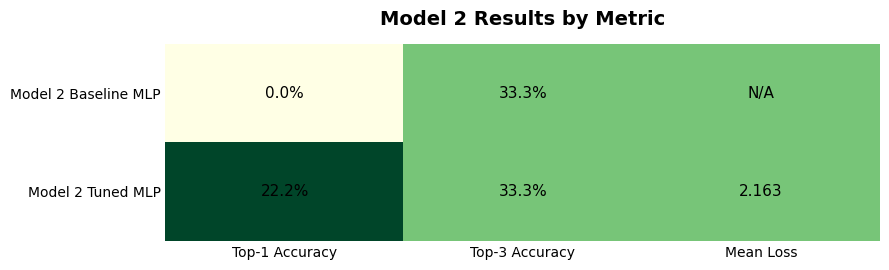

,Rank,top1_correct,top1_std,top3_correct,top3_std,mean_loss,num_epochs,lr,patience,dropout,weight_decay,mlp_hidden_dim,label_smoothing,best_seed
0,1,1.333333,0.471405,3.000000,0.000000,2.166782,160,0.0001,8,0.65,0.05,32,0.03,101
1,2,1.333333,0.471405,3.000000,0.000000,2.169718,120,0.0001,16,0.50,0.00,32,0.00,101
2,3,1.333333,0.471405,2.666667,0.471405,2.162947,80,0.0001,8,0.50,0.00,32,0.03,101
3,4,1.333333,0.471405,2.333333,0.471405,2.171227,80,0.0001,12,0.50,0.05,128,0.00,13
4,5,1.000000,0.000000,3.000000,0.000000,2.325555,80,0.0003,8,0.30,0.05,64,0.07,37
5,6,0.666667,0.471405,3.000000,0.000000,2.463148,80,0.0010,12,0.65,0.05,32,0.03,37
6,7,0.666667,0.471405,3.000000,0.000000,2.484545,80,0.0007,12,0.50,0.05,32,0.00,13
7,8,0.666667,0.471405,3.000000,0.000000,2.580776,120,0.0010,8,0.65,0.01,32,0.00,37


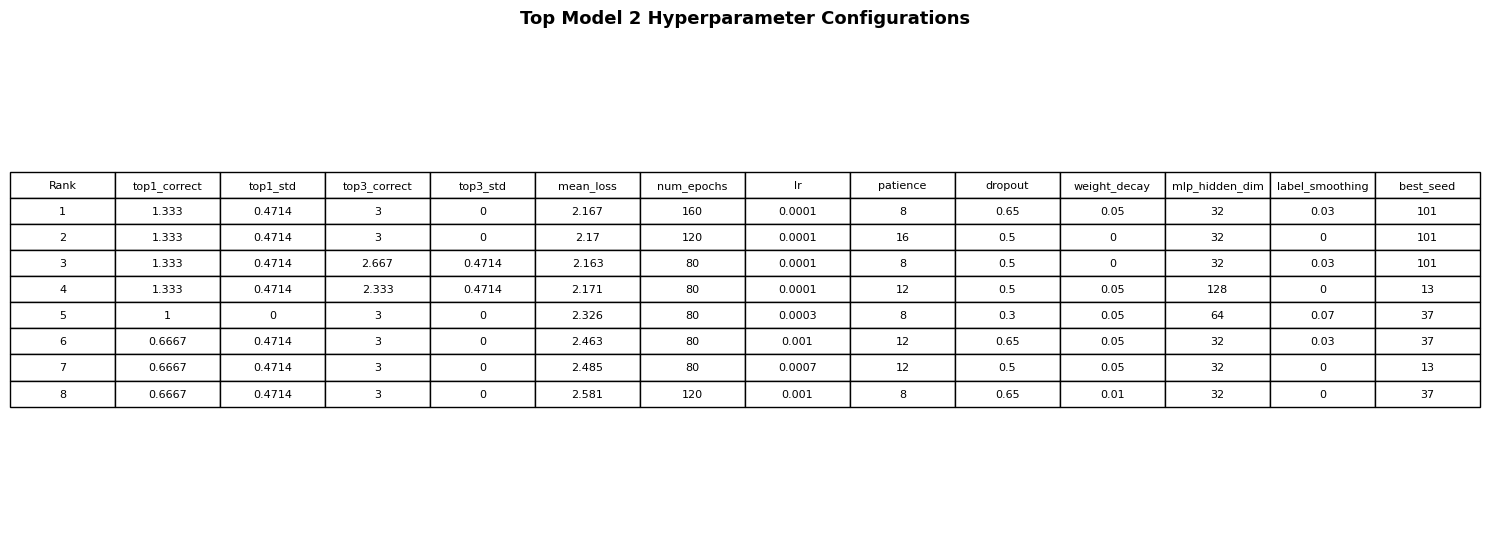

Saved presentation outputs:
- outputs/model2_results_table.csv
- outputs/model2_metric_grid.png
- outputs/model2_top_configs.csv
- outputs/model2_top_configs_table.png


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)


def summarize_model2_run(results, model_name):
    total = len(results)
    top1_correct = sum(bool(r["correct"]) for r in results)
    top3_correct = count_top_k(results, k=3)
    losses = [r.get("loss", np.nan) for r in results]
    losses = [loss for loss in losses if not pd.isna(loss)]
    mean_loss = np.mean(losses) if losses else np.nan

    return {
        "Model": model_name,
        "Top-1 Accuracy": top1_correct / total,
        "Top-3 Accuracy": top3_correct / total,
        "Top-1 Correct": top1_correct,
        "Top-3 Correct": top3_correct,
        "Folds": total,
        "Mean Loss": mean_loss,
    }


model2_rows = []
if "results_simple" in globals():
    model2_rows.append(summarize_model2_run(results_simple, "Model 2 Baseline MLP"))
if "results_simple_tuned" in globals():
    model2_rows.append(summarize_model2_run(results_simple_tuned, "Model 2 Tuned MLP"))
if not model2_rows:
    raise ValueError("Run the Model 2 baseline or tuning cell before creating presentation results.")

model2_results_table = pd.DataFrame(model2_rows)
model2_results_table.to_csv("outputs/model2_results_table.csv", index=False)

display(
    model2_results_table.style.format({
        "Top-1 Accuracy": "{:.1%}",
        "Top-3 Accuracy": "{:.1%}",
        "Mean Loss": "{:.4f}",
    })
)


# Model on y-axis, metrics on x-axis. Color is normalized per metric column.
plot_cols = ["Top-1 Accuracy", "Top-3 Accuracy", "Mean Loss"]
plot_data = model2_results_table.set_index("Model")[plot_cols]
color_data = plot_data.copy().astype(float)

for col in color_data.columns:
    col_min = color_data[col].min()
    col_max = color_data[col].max()
    if pd.isna(col_min) or pd.isna(col_max) or col_min == col_max:
        color_data[col] = 0.5
    else:
        color_data[col] = (color_data[col] - col_min) / (col_max - col_min)
        if col == "Mean Loss":
            color_data[col] = 1 - color_data[col]

annotations = plot_data.copy()
for col in ["Top-1 Accuracy", "Top-3 Accuracy"]:
    annotations[col] = annotations[col].map(lambda value: f"{value:.1%}")
annotations["Mean Loss"] = annotations["Mean Loss"].map(
    lambda value: "N/A" if pd.isna(value) else f"{value:.3f}"
)

fig, ax = plt.subplots(figsize=(9, 1.4 + 0.7 * len(plot_data)))
im = ax.imshow(color_data.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(plot_cols)))
ax.set_xticklabels(plot_cols)
ax.set_yticks(range(len(plot_data.index)))
ax.set_yticklabels(plot_data.index)
ax.set_title("Model 2 Results by Metric", pad=14, fontsize=14, fontweight="bold")

for i in range(len(plot_data.index)):
    for j in range(len(plot_cols)):
        ax.text(j, i, annotations.iloc[i, j], ha="center", va="center", fontsize=11)

ax.tick_params(axis="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()
fig.savefig("outputs/model2_metric_grid.png", dpi=300, bbox_inches="tight")
plt.show()


# Top tuning configurations table for backup slides.
top_config_cols = [
    "top1_correct", "top1_std", "top3_correct", "top3_std", "mean_loss",
    "num_epochs", "lr", "patience", "dropout", "weight_decay",
    "mlp_hidden_dim", "label_smoothing", "best_seed",
]
top_model2_configs = tuning_df_simple[top_config_cols].head(8).copy()
top_model2_configs.insert(0, "Rank", range(1, len(top_model2_configs) + 1))
top_model2_configs.to_csv("outputs/model2_top_configs.csv", index=False)
display(top_model2_configs)

table_display = top_model2_configs.copy()
for col in ["top1_correct", "top1_std", "top3_correct", "top3_std", "mean_loss", "lr", "dropout", "weight_decay", "label_smoothing"]:
    table_display[col] = table_display[col].map(lambda value: f"{value:.4g}")

fig, ax = plt.subplots(figsize=(15, 0.55 * len(table_display) + 1.2))
ax.axis("off")
table = ax.table(
    cellText=table_display.values,
    colLabels=table_display.columns,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.35)
ax.set_title("Top Model 2 Hyperparameter Configurations", pad=12, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("outputs/model2_top_configs_table.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved presentation outputs:")
print("- outputs/model2_results_table.csv")
print("- outputs/model2_metric_grid.png")
print("- outputs/model2_top_configs.csv")
print("- outputs/model2_top_configs_table.png")


In [28]:
results_best = run_loocv_simple_tuned(
    cache=cache_st,
    nominees_df=nominees_df_filtered,
    device=device,
    verbose=True,
    **{
        key: best_model2_params[key]
        for key in [
            "num_epochs",
            "lr",
            "patience",
            "dropout",
            "weight_decay",
            "mlp_hidden_dim",
            "label_smoothing",
        ]
    },
    seed=int(best_model2_params["best_seed"]),
)

summarize_results(results_best, k=3)



Fold: test year = 2012  [Simple MLP]
  Epoch 010 | loss 2.1423 | train acc 3/8
  Epoch 020 | loss 2.1027 | train acc 7/8
  Epoch 030 | loss 2.1041 | train acc 5/8
  Epoch 040 | loss 2.0598 | train acc 7/8
  Epoch 050 | loss 2.0303 | train acc 7/8
  Epoch 060 | loss 2.0023 | train acc 6/8
  Epoch 070 | loss 1.9596 | train acc 8/8
  Epoch 080 | loss 1.9275 | train acc 8/8
  Epoch 090 | loss 1.9174 | train acc 7/8
  Epoch 100 | loss 1.8783 | train acc 8/8
  Epoch 110 | loss 1.8765 | train acc 7/8
  Epoch 120 | loss 1.8478 | train acc 8/8
  Early stopping at epoch 120 (best epoch 112, loss 1.8286)

  Results for 2012:
    The Artist                                    0.112 <- winner
    The Descendants                               0.109
    Extremely Loud and Incredibly Close           0.109
    The Help                                      0.127 <- predicted
    Hugo                                          0.104
    Midnight in Paris                             0.115
    Moneyball     

(2, 3)

### **Model 3: TF-IDF Basic Concatenation**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp


# ── TEXT PREPARATION ──────────────────────────────────────────────────────────
def prepare_texts(nominees_df, metacritic_df, imdb_df, year):
    """
    For a given year, concatenate all critic reviews and all IMDb reviews
    into one string per film. Returns list of (film, critic_text, imdb_text, is_winner).
    """
    year_nominees = nominees_df[nominees_df["ceremony_year"] == year]
    films         = year_nominees["film_title"].tolist()
    winner_row    = year_nominees[year_nominees["winner"] == 1]
    winner_title  = winner_row["film_title"].iloc[0] if not winner_row.empty else None

    film_data = []

    for film in films:
        # Concatenate all critic quotes into one string
        critic_texts = metacritic_df[
            (metacritic_df["film_title"]    == film) &
            (metacritic_df["ceremony_year"] == year)
        ]["clean_text"].dropna().tolist()

        # Concatenate all IMDb reviews into one string
        imdb_texts = imdb_df[
            (imdb_df["film_title"]    == film) &
            (imdb_df["ceremony_year"] == year)
        ]["clean_text"].dropna().tolist()

        critic_combined = " ".join(critic_texts) if critic_texts else "no reviews"
        imdb_combined   = " ".join(imdb_texts)   if imdb_texts   else "no reviews"
        is_winner       = 1 if film == winner_title else 0

        film_data.append({
            "film":          film,
            "critic_text":   critic_combined,
            "imdb_text":     imdb_combined,
            "is_winner":     is_winner,
        })

    return film_data


# ── TFIDF MODEL ───────────────────────────────────────────────────────────────
class OscarPredictorTFIDF:
    """
    Model 3 — TF-IDF + Logistic Regression.
    Non-neural baseline. No embeddings, no training loop, no GPU.

    Critic and IMDb reviews are each vectorized with separate TF-IDF
    vectorizers then concatenated into one feature vector per film.
    Logistic regression predicts P(winner).

    Purpose: sanity check baseline.
    If neural models don't beat this, something is wrong with the
    neural pipeline or the data is too noisy for any model.
    """
    def __init__(self, max_features=5000, C=0.01):
        # Separate vectorizers — critic and audience use different vocabulary
        # min_df=1 because corpus is tiny (77 films total)
        self.critic_vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),      # unigrams + bigrams
            sublinear_tf=True,       # log normalization on term frequency
            strip_accents="unicode",
            min_df=1,
        )
        self.imdb_vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),
            sublinear_tf=True,
            strip_accents="unicode",
            min_df=1,
        )
        # C=0.01 — heavy regularization essential for small dataset
        # class_weight="balanced" — corrects 1 winner vs 8 nominees imbalance
        self.classifier = LogisticRegression(
            C=C,
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )

    def _build_features(self, film_data_list, fit=False):
        """
        Vectorize critic and IMDb texts and concatenate.
        fit=True during training, fit=False during test (transform only).

        returns: sparse matrix [n_films, max_features * 2]
        """
        critic_texts = [d["critic_text"] for d in film_data_list]
        imdb_texts   = [d["imdb_text"]   for d in film_data_list]

        if fit:
            critic_features = self.critic_vectorizer.fit_transform(critic_texts)
            imdb_features   = self.imdb_vectorizer.fit_transform(imdb_texts)
        else:
            critic_features = self.critic_vectorizer.transform(critic_texts)
            imdb_features   = self.imdb_vectorizer.transform(imdb_texts)

        # Horizontally stack critic and IMDb features
        return sp.hstack([critic_features, imdb_features])

    def fit(self, film_data_list):
        """Train on a list of film dicts (from multiple years)."""
        X = self._build_features(film_data_list, fit=True)
        y = np.array([d["is_winner"] for d in film_data_list])
        self.classifier.fit(X, y)

    def predict_proba(self, film_data_list):
        """
        Returns P(winner) for each film.
        Normalized to sum to 1 across cohort for comparability
        with softmax outputs from neural models.
        """
        X     = self._build_features(film_data_list, fit=False)
        probs = self.classifier.predict_proba(X)[:, 1]  # P(winner)

        # Normalize across cohort — sum to 1
        total = probs.sum()
        if total > 0:
            probs = probs / total

        return probs


# ── LOOCV ─────────────────────────────────────────────────────────────────────
def run_loocv_tfidf(nominees_df, metacritic_df, imdb_df,
                    max_features=5000, C=0.01):
    """
    Leave-one-year-out cross validation for TF-IDF model.
    Fits vectorizer and classifier on training years only.
    Transforms test year using training vocabulary — no leakage.
    """
    all_years = sorted(nominees_df["ceremony_year"].unique())
    results   = []

    for test_year in all_years:
        print(f"\n{'='*56}")
        print(f"Fold: test year = {test_year}  [TF-IDF]")
        print(f"{'='*56}")

        train_years = [y for y in all_years if y != test_year]

        # Build training data — all films from all training years
        train_data = []
        for year in train_years:
            train_data.extend(prepare_texts(nominees_df, metacritic_df, imdb_df, year))

        # Build test data — films from held-out year only
        test_data = prepare_texts(nominees_df, metacritic_df, imdb_df, test_year)

        print(f"  Train: {len(train_data)} films ({sum(d['is_winner'] for d in train_data)} winners)")
        print(f"  Test:  {len(test_data)} films")

        # Fit on training data, transform test data
        model = OscarPredictorTFIDF(max_features=max_features, C=C)
        model.fit(train_data)
        probs = model.predict_proba(test_data)

        # Find winner and prediction
        true_idx = next(i for i, d in enumerate(test_data) if d["is_winner"] == 1)
        pred_idx = probs.argmax()
        correct  = (pred_idx == true_idx)
        films    = [d["film"] for d in test_data]

        # Print results
        print(f"\n  Results for {test_year}:")
        for i, (film, prob) in enumerate(zip(films, probs)):
            w = " ← winner"    if i == true_idx else ""
            p = " ← predicted" if i == pred_idx else ""
            print(f"    {film:45s} {prob:.3f}{w}{p}")

        results.append({
            "test_year": test_year,
            "correct":   correct,
            "winner":    films[true_idx],
            "predicted": films[pred_idx],
            "probs":     probs.tolist(),
            "films":     films,
        })

    # Summary
    print(f"\n{'='*56}")
    print(f"TF-IDF LOOCV Summary")
    print(f"{'='*56}")
    for r in results:
        mark = "✓" if r["correct"] else "✗"
        print(f"  {mark} {r['test_year']} | "
              f"predicted: {r['predicted']:40s} | "
              f"actual: {r['winner']}")

    accuracy = sum(r["correct"] for r in results) / len(results)
    print(f"\nOverall: {sum(r['correct'] for r in results)}/{len(results)} = {accuracy:.1%}")
    print(f"Random baseline: ~12.5%")

    return results


# ── SUMMARIZE WITH TOP-K ───────────────────────────────────────────────────────
def summarize_results_tfidf(results, k=3):
    top1_correct = 0
    topk_correct = 0

    print(f"\n{'='*56}")
    print(f"TF-IDF Results Summary (Top-1 and Top-{k})")
    print(f"{'='*56}")

    for r in results:
        winner    = r["winner"]
        predicted = r["predicted"]
        probs     = r["probs"]
        films     = r["films"]

        ranked      = sorted(zip(films, probs), key=lambda x: x[1], reverse=True)
        top_k_films = [f for f, p in ranked[:k]]

        in_top1 = (predicted == winner)
        in_topk = (winner in top_k_films)

        top1_correct += int(in_top1)
        topk_correct += int(in_topk)

        mark1 = "✓" if in_top1 else "✗"
        markk = "✓" if in_topk else "✗"

        print(f"  {r['test_year']} | Top-1 {mark1} | Top-{k} {markk} | "
              f"predicted: {predicted:35s} | actual: {winner}")

    total = len(results)
    print(f"\nTop-1 accuracy : {top1_correct}/{total} = {top1_correct/total:.1%}")
    print(f"Top-{k} accuracy : {topk_correct}/{total} = {topk_correct/total:.1%}")
    print(f"Random Top-1   : ~12.5%")
    print(f"Random Top-{k}   : ~{k/9:.1%}")

    return top1_correct, topk_correct

In [ ]:
# ------------ C = 20 ------------
for C in [20.0]:
    print(f"\n{'#'*56}")
    print(f"# C = {C}")
    print(f"{'#'*56}")
    results_tfidf = run_loocv_tfidf(
        nominees_df   = nominees_df_filtered,
        metacritic_df = metacritic_df,
        imdb_df       = imdb_df,
        max_features  = 5000,
        C             = C
    )
    summarize_results_tfidf(results_tfidf, k=3)

## Evaluation (NEEDS TO BE IMPLEMENTED)
Methods:
  - Accuracy
  - Top-1, Top-5
  - Others?